# Manuscript figure plotting notebook

This notebook loads the numerical data used for the manuscript figures and saves every generated PDF in one output folder.

## Expected folder structure

```text
project_folder/
├── Data/
├── Final_Results/
└── Manuscript_Figure_Plots.ipynb
```

The `Final_Results` folder is created automatically when the setup cell is run.

## How to generate a figure

1. Place this notebook in the project folder containing the `Data` directory.
2. Run the notebook cells once to load the setup, readers, and plotting functions.
3. Go to the final **Plot control** cell.
4. Uncomment and run the command for the required figure.

For example:

```python
plot_fig10(N=35, Jf=0.45, P_index=-2)
```

Figures 5–8 use a cached data loader. After changing their source `.dat` files, run `clear_fig5_cache()` before plotting them again.


In [1]:
# ============================================================
# SETUP AND COMMON UTILITIES
# Run this cell once before using any plotting function.
# ============================================================

from pathlib import Path
from functools import lru_cache
import math
import os
import sys
import time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.colors import Normalize
import scipy as sp
import scipy.sparse as sps
import scipy.optimize as optimization
from scipy.linalg import eigh

np.set_printoptions(suppress=True, precision=3)

# Project, data, and figure directories.
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "Data"
FIGURE_DIR = PROJECT_ROOT / "Final_Results"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Shared plotting styles used throughout the manuscript figures.
STYLES = {
    "DCQO":      {"color": "tab:blue",   "marker": "^"},
    "DCQO_noCD": {"color": "tab:purple", "marker": "v"},
    "QAOA":      {"color": "tab:orange", "marker": "o"},
    "DC-QAOA":   {"color": "tab:green",  "marker": "s"},
    "Cubic":     {"color": "tab:red",    "marker": "d"},
}

COLORS = [
    "#9467bd", "#983d0f", "#0a939a", "#2e1fd3", "#ef4d4d",
    "#f245f8", "#2AD262", "#7f7f7f", "#8e8e04", "#4B94D0",
]


def configure_matplotlib():
    """Apply the LaTeX/serif formatting used by all manuscript figures."""
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath}",
    })


def require_file(path):
    """Return Path(path), or raise an informative error before plotting."""
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            "Required data file was not found:\n"
            f"  {path}\n\n"
            "Check PROJECT_ROOT, N, Jf, P_index, and the data directory structure."
        )
    return path


def ensure_directory(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def normalized_steps(length, start_at_one=True):
    """Return p/P for an array of the supplied length."""
    if length <= 0:
        raise ValueError("A plotted array must contain at least one value.")
    if start_at_one:
        return np.arange(1, length + 1, dtype=float) / length
    return np.arange(length, dtype=float) / length


configure_matplotlib()
print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"DATA_ROOT    = {DATA_ROOT}")
print(f"FIGURE_DIR  = {FIGURE_DIR}")


PROJECT_ROOT = c:\Users\kiran\OneDrive - SISSA\Desktop\Folder_GitHub
DATA_ROOT    = c:\Users\kiran\OneDrive - SISSA\Desktop\Folder_GitHub\Data
FIGURE_DIR  = c:\Users\kiran\OneDrive - SISSA\Desktop\Folder_GitHub\Final_Results


## Figures 2a and 2b — energy gaps

In [2]:
# ============================================================
# FIGURE 2 HELPERS AND PLOTTING FUNCTIONS
# ============================================================


def read_fig2a_data(filename, n_s):
    filename = require_file(filename)
    with filename.open("r", encoding="utf-8") as handle:
        lines = handle.readlines()

    n_value = lines[0].split()[2]
    jf_value = lines[1].split()[2]
    s_values = [float(lines[3].split()[i]) for i in range(n_s)]
    gaps = [float(lines[5].split()[i]) for i in range(n_s)]
    return n_value, jf_value, np.asarray(gaps), np.asarray(s_values)


def plot_fig2a(
    N=17,
    Jf_values=(0.2501, 0.30, 0.35, 0.40, 0.45),
    n_s=10001,
):
    """Plot Fig. 2a: instantaneous energy gap."""
    configure_matplotlib()
    data_dir = DATA_ROOT / "System_Dynamics_And_Methods" / "Fig2a"

    gap_lists = []
    schedules = []
    for Jf in Jf_values:
        filename = data_dir / f"DataForEnergyGap_s_N_{N}_Jf_{Jf}.dat"
        _, _, gaps, s_values = read_fig2a_data(filename, n_s)
        gap_lists.append(gaps)
        schedules.append(s_values)

    line_styles = [
        "-", "--", "-.", ":", (0, (10, 2)),
        (0, (1, 1)), (0, (5, 1)), (0, (3, 1, 1, 1)),
        (0, (5, 5)), (0, (3, 5, 1, 5)),
    ]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.tick_params(axis="both", labelsize=20)

    for index, Jf in enumerate(Jf_values):
        ax.plot(
            schedules[index],
            gap_lists[index],
            linestyle=line_styles[index],
            color=COLORS[index],
            label=rf"$J_{{f}} = {Jf}$",
        )

    ax.annotate(
        r"$(s_a,\Delta_{s_a})$",
        xy=(0.62, 0.1),
        xytext=(0.58, 0.18),
        fontsize=21,
        color=COLORS[1],
        arrowprops=dict(
            facecolor="black", shrink=0.06, width=0.8,
            alpha=0.4, headwidth=6,
        ),
    )

    ax.text(0.31, 0.004, r"$(s_b,\Delta_{\mathrm{min}})$", fontsize=21, ha="center")

    for point in [
        (0.62, 0.058),
        (0.645, 0.025),
        (0.7, 0.005),
        (0.82, 3.219772430895773e-06),
        (0.93, 3.219772430895773e-06),
    ]:
        ax.annotate(
            "",
            xy=point,
            xytext=(0.39, 0.00),
            arrowprops=dict(
                facecolor="black", shrink=0.06, width=0.8,
                alpha=0.4, headwidth=6,
            ),
        )

    ax.text(
        0.17, 0.02, rf"$\mathrm{{N}} = {N}$",
        fontsize=20, va="top", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
    )
    ax.set_xlabel(r"$s$", fontsize=25)
    ax.set_ylabel(r"$\Delta_s/J$", fontsize=20)
    ax.set_ylim(0, 0.2)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=20)
    fig.tight_layout()

    output_file = FIGURE_DIR / f"EnergyGapVsSchedule_N_{N}.pdf"
    fig.savefig(output_file)
    plt.show()
    print(f"Saved: {output_file}")
    return fig, ax, output_file


def read_fig2b_data(filename, n_points=10):
    filename = require_file(filename)
    with filename.open("r", encoding="utf-8") as handle:
        lines = handle.readlines()

    jf_value = lines[0].split()[2]
    n_values = [float(lines[2].split()[i]) for i in range(n_points)]
    min_gaps = [float(lines[4].split()[i]) for i in range(n_points)]
    min_locations = [float(lines[6].split()[i]) for i in range(n_points)]
    return jf_value, np.asarray(n_values), np.asarray(min_gaps), np.asarray(min_locations)


def plot_fig2b(
    Jf_values=(0.2501, 0.3, 0.35, 0.4, 0.45),
    n_points=10,
):
    """Plot Fig. 2b: minimum energy gap versus N."""
    configure_matplotlib()
    data_dir = DATA_ROOT / "System_Dynamics_And_Methods" / "Fig2b"
    symbols = ["-o", "-x", "-v", "-^", "-s"]

    fig, ax = plt.subplots(figsize=(7, 5))
    final_n_values = None

    for index, Jf in enumerate(Jf_values):
        filename = data_dir / f"DataForEnergyGap_Jf_{Jf}.dat"
        jf_read, n_values, min_gaps, _ = read_fig2b_data(filename, n_points)
        final_n_values = n_values
        ax.plot(
            n_values,
            min_gaps,
            symbols[index],
            color=COLORS[index],
            label=rf"$J_f={jf_read}$",
        )

    ax.set_xticks(final_n_values)
    ax.tick_params(axis="both", labelsize=20)
    ax.set_xlabel(r"$\mathrm{N}$", fontsize=20)
    ax.set_ylabel(r"$\Delta_{\mathrm{min}}/J$", fontsize=20)
    ax.set_yscale("log")
    ax.legend(fontsize=20)
    fig.tight_layout()

    output_file = FIGURE_DIR / "MinEnergyGapVsN.pdf"
    fig.savefig(output_file)
    plt.show()
    print(f"Saved: {output_file}")
    return fig, ax, output_file


## Figures 3 and 4 — fixed schedules and residual-energy histograms

In [3]:
# ============================================================
# FIGURE 3 AND FIGURE 4 FUNCTIONS
# ============================================================


def read_fig3_data(filename, n_p, n_dt):
    filename = require_file(filename)
    with filename.open("r", encoding="utf-8") as handle:
        lines = handle.readlines()

    dt_values = [abs(float(lines[1].split()[i])) for i in range(n_dt)]
    p_values = [abs(float(lines[2].split()[i])) for i in range(n_p)]
    residuals = []
    for i in range(n_dt):
        residuals.append([
            abs(float(lines[3 + i].split()[j])) for j in range(n_p)
        ])
    return np.asarray(dt_values), np.asarray(p_values), np.asarray(residuals)


def _load_fig3_schedule(data_dir, N, Jf, schedule, n_p, n_dt):
    filename = data_dir / f"OUTPUT_file_N_{N}Jf_{Jf}{schedule}.dat"
    dt_values, p_values, residuals = read_fig3_data(filename, n_p, n_dt)
    return dt_values, p_values, residuals / N


def plot_fig3(N=17, n_p=41, n_dt=1):
    """Plot Fig. 3: residual energy for nearly continuous-time evolution."""
    configure_matplotlib()
    data_dir = DATA_ROOT / "Results" / "Fig3"
    symbols = [":", "--", "-", ":", "--", "-", ":x", "--x"]

    fig, axes = plt.subplots(2, 1, sharex=True, figsize=(7, 5))
    j = 0

    # Top panel: Jf = 0.2501
    Jf_top = 0.2501
    top = {
        schedule: _load_fig3_schedule(data_dir, N, Jf_top, schedule, n_p, n_dt)
        for schedule in ("linear", "cubic", "sine")
    }
    dt_top, p_top, _ = top["linear"]
    tau_top = p_top * dt_top[j]

    for schedule, style_index in zip(("linear", "cubic", "sine"), (0, 1, 2)):
        residual = top[schedule][2]
        axes[0].plot(
            tau_top,
            np.abs(residual[j]),
            symbols[style_index],
            color=COLORS[0],
            markerfacecolor="none",
        )

    tau_ad = 318
    axes[0].axvline(x=tau_ad, color="blue", linestyle="--", linewidth=1.5)
    axes[0].text(
        tau_ad * 1.1, 1, r"$\tau_{\mathrm{ad}}=318$",
        color="blue", fontsize=20, rotation=0, verticalalignment="center",
    )
    axes[0].text(
        0.4, 0.8, rf"$J_f={Jf_top}$",
        transform=axes[0].transAxes, fontsize=16,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    # Bottom panel: Jf = 0.45
    Jf_bottom = 0.45
    bottom = {
        schedule: _load_fig3_schedule(data_dir, N, Jf_bottom, schedule, n_p, n_dt)
        for schedule in ("linear", "cubic", "sine")
    }
    dt_bottom, p_bottom, _ = bottom["linear"]
    tau_bottom = p_bottom * dt_bottom[j]

    for schedule, style_index in zip(("linear", "cubic", "sine"), (3, 4, 5)):
        residual = bottom[schedule][2]
        axes[1].plot(
            tau_bottom,
            np.abs(residual[j]),
            symbols[style_index],
            color=COLORS[4],
            markerfacecolor="none",
        )

    axes[1].text(
        0.4, 0.8, rf"$J_f={Jf_bottom}$",
        transform=axes[1].transAxes, fontsize=16,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    for axis in axes:
        axis.set_xscale("log")
        axis.set_yscale("log")
        axis.set_xlim(1, 5000)
        axis.set_ylim(1e-3, 3)
        axis.tick_params(axis="both", labelsize=20)

    axes[1].set_xlabel(r"$\tau$", fontsize=25)
    fig.text(
        0.03, 0.52,
        r"$\epsilon^{\mathrm{res}}_{\scriptscriptstyle\mathrm{P}}$",
        fontsize=25, va="center", rotation="vertical",
    )

    legend_handles = [
        mlines.Line2D([], [], color="gray", linestyle=":", label=r"$s^{(\mathrm{lin})}$"),
        mlines.Line2D([], [], color="gray", linestyle="--", label=r"$s^{(\mathrm{cub})}$"),
        mlines.Line2D([], [], color="gray", linestyle="-", label=r"$s^{(\mathrm{sin})}$"),
    ]
    axes[1].legend(handles=legend_handles, loc="upper right", fontsize=20)

    fig.tight_layout()
    fig.subplots_adjust(left=0.15)
    output_file = FIGURE_DIR / f"ResidualEnergy_with_fixed_schedule_N_{N}.pdf"
    fig.savefig(output_file)
    plt.show()
    print(f"Saved: {output_file}")
    return fig, axes, output_file


def read_fig4_data(filename, n_realizations):
    filename = require_file(filename)
    with filename.open("r", encoding="utf-8") as handle:
        lines = handle.readlines()
    return np.asarray([
        abs(float(lines[1].split()[i])) for i in range(n_realizations)
    ])


def plot_fig4(
    N=17,
    Jf_values=(0.2501, 0.45),
    P_values=(47, 48),
    n_realizations=200,
):
    """Plot Fig. 4: histograms of residual energies."""
    configure_matplotlib()
    data_dir = DATA_ROOT / "Results" / "Fig4"
    bar_colors = {47: "green", 48: "orange"}
    hatch_patterns = {47: "\\\\", 48: ""}
    alpha = 0.8

    fig, axes = plt.subplots(
        2, 1, sharex=True, figsize=(7, 5),
        gridspec_kw={"hspace": 0.05},
    )

    for axis in axes:
        position = axis.get_position()
        axis.set_position([
            position.x0,
            position.y0 + 0.04,
            position.width,
            position.height,
        ])

    for axis, Jf in zip(axes, Jf_values):
        data_by_p = {}
        for P in P_values:
            filename = data_dir / f"DataForPcr_N_{N}_P_{P}_Jf_{Jf}.dat"
            data_by_p[P] = read_fig4_data(filename, n_realizations)

        all_data = np.concatenate(list(data_by_p.values()))
        min_exp = -17
        max_exp = int(np.ceil(np.log10(all_data.max())))
        bins = np.logspace(min_exp, max_exp, max_exp - min_exp + 1)

        for P in P_values:
            values = data_by_p[P]
            histogram, bin_edges = np.histogram(values, bins=bins)
            histogram = histogram / histogram.sum() * 100
            axis.bar(
                bin_edges[:-1],
                histogram,
                width=np.diff(bin_edges),
                align="edge",
                edgecolor="black",
                color=bar_colors[P],
                alpha=alpha,
                hatch=hatch_patterns[P],
                label=rf"$N_{{\boldsymbol{{\theta}}}}={3 * P}$",
            )

        axis.axvline(x=1e-12, color="red", linestyle="--", linewidth=1.5)
        if axis is axes[-1]:
            axis.text(
                1.3e-12,
                axis.get_ylim()[1] * 0.85,
                r"$\epsilon^{\mathrm{res}}_{\mathrm{P}}=10^{-12}$",
                color="red", fontsize=18, rotation=90, ha="left", va="top",
            )

        axis.set_xscale("log")
        axis.grid(True, axis="y", linestyle="--", linewidth=0.5)
        axis.tick_params(axis="both", labelsize=18)
        axis.text(
            4e-13,
            axis.get_ylim()[1] * 0.9,
            rf"$J_{{f}} = {Jf}$",
            fontsize=18, ha="right", va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
        )

    axes[0].legend(fontsize=20)
    axes[-1].set_xlabel(
        r"$\epsilon^{\mathrm{res}}_{\mathrm{P}}$", fontsize=22, labelpad=1,
    )
    fig.text(0.04, 0.5, "Percentage", va="center", rotation="vertical", fontsize=22)
    axes[-1].tick_params(axis="x", pad=10)
    axes[-1].set_xlim(1e-17, 1e1)

    output_file = FIGURE_DIR / f"Controllability_N_{N}_Jf_compare.pdf"
    fig.savefig(output_file)
    plt.show()
    print(f"Saved: {output_file}")
    return fig, axes, output_file


## Shared data loader for Figures 5–8

`load_fig5_data(...)` reads the fixed-schedule and optimized-method data used by Figures 5–8 and returns them in one structured dictionary. The loaded data are cached for repeated plotting.


In [4]:
# ============================================================
# SHARED READERS AND CACHED DATA LOADER FOR FIGURES 5–8
# ============================================================


def read_dcqo_analytical_file(filename):
    filename = require_file(filename)
    with filename.open("r", encoding="utf-8") as handle:
        lines = handle.readlines()

    P = int(lines[3].split()[-1])
    Nc = int(lines[4].split()[-1])

    pulses = np.zeros(Nc, dtype=float)
    theta_z_coeff = np.zeros(Nc, dtype=float)
    for m in range(Nc):
        pulses[m], theta_z_coeff[m] = lines[10:10 + Nc][m][:-1].split()[1::]

    theta_z = np.zeros(P, dtype=float)
    theta_x = np.zeros(P, dtype=float)
    theta_xz = np.zeros(P, dtype=float)
    for m in range(P):
        theta_z[m], theta_x[m], theta_xz[m], _ = (
            lines[10 + Nc + 2:10 + Nc + 2 + P][m][:-1].split()[5::]
        )

    for m in range(P):
        while theta_x[m] > np.pi / 2:
            theta_x[m] -= np.pi / 2
        while theta_x[m] < -1:
            theta_x[m] += np.pi / 2

    residual_energy = float(lines[-2].split()[-1])
    elapsed_time = float(lines[-1].split()[-2])

    return (
        P, Nc, theta_z, theta_x, theta_xz, pulses,
        theta_z_coeff, residual_energy, elapsed_time,
    )


def read_crab_file(filename):
    """Reader used for DC-QAOA and QAOA CRAB result files."""
    filename = require_file(filename)
    with filename.open("r", encoding="utf-8") as handle:
        lines = handle.readlines()

    P = int(lines[3].split()[-1])
    Nc = int(lines[4].split()[-1])

    pulses = np.zeros(Nc, dtype=float)
    theta_z_coeff = np.zeros(Nc, dtype=float)
    theta_x_coeff = np.zeros(Nc, dtype=float)
    theta_xz_coeff = np.zeros(Nc, dtype=float)

    for m in range(Nc):
        (
            pulses[m], theta_z_coeff[m], theta_x_coeff[m], theta_xz_coeff[m]
        ) = lines[10:10 + Nc][m][:-1].split()[3::]

    theta_z = np.zeros(P, dtype=float)
    theta_x = np.zeros(P, dtype=float)
    theta_xz = np.zeros(P, dtype=float)
    for m in range(P):
        theta_z[m], theta_x[m], theta_xz[m] = (
            lines[10 + Nc + 2:10 + Nc + 2 + P][m][:-1].split()[4::]
        )

    for m in range(P):
        while theta_x[m] > np.pi / 2:
            theta_x[m] -= np.pi / 2
        while theta_x[m] < -1:
            theta_x[m] += np.pi / 2

    residual_energy = float(lines[-2].split()[-4])
    elapsed_time = float(lines[-1].split()[-2])

    return (
        P, Nc, theta_z, theta_x, theta_xz, pulses,
        theta_z_coeff, theta_x_coeff, theta_xz_coeff,
        residual_energy, elapsed_time,
    )


def _load_fixed_schedules(base_dir, N, Jf, n_p, n_reals):
    schedules = ("linear", "cubic", "sine")
    fixed_data = {}

    for schedule in schedules:
        method_dir = base_dir / "DCQO_with_fixed_schedule" / schedule / f"N{N}Jf{Jf}"

        residuals = np.zeros(n_p, dtype=float)
        tau = np.zeros(n_p, dtype=float)
        tau_abs = np.zeros(n_p, dtype=float)
        p_list = np.zeros(n_p, dtype=int)

        theta_z_all = []
        theta_x_all = []
        theta_xz_all = []
        coefficients_z = []
        pulses_all = []

        for p_index in range(n_p):
            P = (p_index + 1) * 6
            p_list[p_index] = P
            Nc = math.floor(P)
            filename = method_dir / f"DCQO_tau_{P}_dt_1Nc{Nc}_nreals_{n_reals}.dat"

            (
                _, _, theta_z, theta_x, theta_xz, pulses,
                coefficient_z, residuals[p_index], _,
            ) = read_dcqo_analytical_file(filename)

            theta_z_all.append(theta_z)
            theta_x_all.append(theta_x)
            theta_xz_all.append(theta_xz)
            coefficients_z.append(coefficient_z)
            pulses_all.append(pulses)

            tau[p_index] = np.sum(theta_x) + np.sum(theta_z)
            tau_abs[p_index] = (
                np.sum(np.abs(theta_x))
                + np.sum(np.abs(theta_z))
                + np.sum(np.abs(theta_xz))
            )

        fixed_data[schedule] = {
            "Plist": p_list,
            "eres": residuals,
            "tau": tau,
            "tau_new": tau_abs,
            "tz": theta_z_all,
            "tx": theta_x_all,
            "txz": theta_xz_all,
            "Cz": coefficients_z,
            "Pulses": pulses_all,
        }

    return fixed_data


def _load_crab_method(
    base_dir,
    N,
    Jf,
    n_p,
    n_reals,
    n_trials,
    folder_name,
    p_factor,
    file_prefix,
):
    residuals = np.zeros((n_trials, n_p))
    tau = np.zeros((n_trials, n_p))
    tau_abs = np.zeros((n_trials, n_p))

    theta_z_all, theta_x_all, theta_xz_all = [], [], []
    coefficients_x_all, coefficients_z_all, coefficients_xz_all = [], [], []
    pulses_all = []

    for trial in range(n_trials):
        method_dir = (
            base_dir / folder_name / f"trail{trial}" / f"N{N}Jf{Jf}" / "iter1"
        )

        theta_z_trial, theta_x_trial, theta_xz_trial = [], [], []
        coefficients_x_trial, coefficients_z_trial, coefficients_xz_trial = [], [], []
        pulses_trial = []

        for p_index in range(n_p):
            P = (p_index + 1) * p_factor
            Nc = math.floor(P)
            filename = method_dir / f"{file_prefix}{P}_dt_1Nc{Nc}_nreals_{n_reals}.dat"

            (
                _, _, theta_z, theta_x, theta_xz, pulses,
                coefficient_z, coefficient_x, coefficient_xz,
                residual_energy, _,
            ) = read_crab_file(filename)

            residuals[trial, p_index] = residual_energy
            tau[trial, p_index] = np.sum(theta_x) + np.sum(theta_z)
            tau_abs[trial, p_index] = (
                np.sum(np.abs(theta_x))
                + np.sum(np.abs(theta_z))
                + np.sum(np.abs(theta_xz))
            )

            theta_z_trial.append(theta_z)
            theta_x_trial.append(theta_x)
            theta_xz_trial.append(theta_xz)
            coefficients_x_trial.append(coefficient_x)
            coefficients_z_trial.append(coefficient_z)
            coefficients_xz_trial.append(coefficient_xz)
            pulses_trial.append(pulses)

        theta_z_all.append(theta_z_trial)
        theta_x_all.append(theta_x_trial)
        theta_xz_all.append(theta_xz_trial)
        coefficients_x_all.append(coefficients_x_trial)
        coefficients_z_all.append(coefficients_z_trial)
        coefficients_xz_all.append(coefficients_xz_trial)
        pulses_all.append(pulses_trial)

    return {
        "eres": residuals,
        "tau": tau,
        "tau_new": tau_abs,
        "tz": theta_z_all,
        "tx": theta_x_all,
        "txz": theta_xz_all,
        "Cx": coefficients_x_all,
        "Cz": coefficients_z_all,
        "Cxz": coefficients_xz_all,
        "Pulses": pulses_all,
        "P_factor": p_factor,
    }


def _load_dcqo_method(base_dir, N, Jf, n_p, n_reals, n_trials, without_cd=False):
    residuals = np.zeros((n_trials, n_p))
    tau = np.zeros((n_trials, n_p))
    tau_abs = np.zeros((n_trials, n_p))

    theta_z_all, theta_x_all, theta_xz_all = [], [], []
    coefficients_z_all, pulses_all = [], []

    folder = "DCQO_without_CD" if without_cd else "DCQO_with_CRAB"
    p_factor = 9 if without_cd else 6
    prefix = "QO_tau_" if without_cd else "DCQO_CRAB_tau_"

    for trial in range(n_trials):
        method_dir = base_dir / folder / f"trail{trial}" / f"N{N}Jf{Jf}" / "iter1"

        theta_z_trial, theta_x_trial, theta_xz_trial = [], [], []
        coefficients_z_trial, pulses_trial = [], []

        for p_index in range(n_p):
            P = (p_index + 1) * p_factor
            Nc = math.floor(P)
            filename = method_dir / f"{prefix}{P}_dt_1Nc{Nc}_nreals_{n_reals}.dat"

            (
                _, _, theta_z, theta_x, theta_xz, pulses,
                coefficient_z, residual_energy, _,
            ) = read_dcqo_analytical_file(filename)

            residuals[trial, p_index] = residual_energy
            tau[trial, p_index] = np.sum(theta_x) + np.sum(theta_z)
            tau_abs[trial, p_index] = (
                np.sum(np.abs(theta_x))
                + np.sum(np.abs(theta_z))
                + np.sum(np.abs(theta_xz))
            )

            theta_z_trial.append(theta_z)
            theta_x_trial.append(theta_x)
            theta_xz_trial.append(theta_xz)
            coefficients_z_trial.append(coefficient_z)
            pulses_trial.append(pulses)

        theta_z_all.append(theta_z_trial)
        theta_x_all.append(theta_x_trial)
        theta_xz_all.append(theta_xz_trial)
        coefficients_z_all.append(coefficients_z_trial)
        pulses_all.append(pulses_trial)

    return {
        "eres": residuals,
        "tau": tau,
        "tau_new": tau_abs,
        "tz": theta_z_all,
        "tx": theta_x_all,
        "txz": theta_xz_all,
        "Cz": coefficients_z_all,
        "Pulses": pulses_all,
        "P_factor": p_factor,
    }


def build_j_array(N, Jw=0.5, Jf=0.45):
    values = np.ones(N, dtype=np.float64)
    values[(N + 1) // 2 - 1] = Jw
    values[(N - 1) // 2 - 1] = Jw
    values[-1] = -Jf
    return values


def analytical_cubic_schedule(N, Jf, P=54):
    p = np.arange(P, dtype=float) + 1
    s = 3.0 * (p / P) ** 2 - 2.0 * (p / P) ** 3
    ds_dp = 6.0 * p / P**2 - 6.0 * p**2 / P**3

    couplings = build_j_array(N, Jf=Jf)
    sum_j2 = np.sum(couplings**2)
    sum_j4 = np.sum(couplings**4)
    sum_j2_next2 = (
        np.sum(couplings[:-1] ** 2 * couplings[1:] ** 2)
        + couplings[-1] ** 2 * couplings[0] ** 2
    )

    alpha = np.zeros(P)
    for index, schedule_value in enumerate(s):
        alpha[index] = sum_j2 / (
            16 * (1 - schedule_value) ** 2 * sum_j2
            + schedule_value**2 * (12 * sum_j2_next2 + 4 * sum_j4)
        )

    return {
        "P": P,
        "x": normalized_steps(P, start_at_one=False),
        "s": s,
        "ds_dp": ds_dp,
        "alpha": alpha,
        "CD": ds_dp * alpha,
    }


@lru_cache(maxsize=None)
def _load_fig5_data_cached(N, Jf, n_p, n_reals, n_trials, analytical_P):
    base_dir = DATA_ROOT / "Results" / "Fig5"

    fixed = _load_fixed_schedules(base_dir, N, Jf, n_p, n_reals)
    dc_qaoa = _load_crab_method(
        base_dir, N, Jf, n_p, n_reals, n_trials,
        folder_name="DC_QAOA_CRAB",
        p_factor=6,
        file_prefix="DCQAOA_CRAB_tau_",
    )
    qaoa = _load_crab_method(
        base_dir, N, Jf, n_p, n_reals, n_trials,
        folder_name="QAOA_CRAB",
        p_factor=9,
        file_prefix="QAOA_CRAB_tau_",
    )
    dcqo = _load_dcqo_method(
        base_dir, N, Jf, n_p, n_reals, n_trials, without_cd=False,
    )
    dcqo_no_cd = _load_dcqo_method(
        base_dir, N, Jf, n_p, n_reals, n_trials, without_cd=True,
    )

    return {
        "N": N,
        "Jf": Jf,
        "N_P": n_p,
        "n_reals": n_reals,
        "n_trials": n_trials,
        "base_dir": base_dir,
        "fixed": fixed,
        "DC-QAOA": dc_qaoa,
        "QAOA": qaoa,
        "DCQO": dcqo,
        "DCQO_noCD": dcqo_no_cd,
        "analytical": analytical_cubic_schedule(N, Jf, P=analytical_P),
    }


def load_fig5_data(
    N=17,
    Jf=0.45,
    n_p=10,
    n_reals=10,
    n_trials=10,
    analytical_P=54,
    refresh=False,
):
    """Load all data required by Figs. 5–8, independently of notebook order."""
    if refresh:
        _load_fig5_data_cached.cache_clear()
    return _load_fig5_data_cached(N, Jf, n_p, n_reals, n_trials, analytical_P)


def clear_fig5_cache():
    """Clear cached Fig. 5–8 data after source files are modified."""
    _load_fig5_data_cached.cache_clear()
    print("Figure 5–8 data cache cleared.")


def compute_log_statistics(values):
    values = np.clip(np.asarray(values), 1e-20, None)
    log_values = np.log(values)
    log_mean = np.mean(log_values, axis=0)
    log_std = np.std(log_values, axis=0)
    mean_linear = np.exp(log_mean)
    lower = mean_linear - np.exp(log_mean - log_std)
    upper = np.exp(log_mean + log_std) - mean_linear
    return mean_linear, lower, upper


def _validate_trial_and_index(method_data, trial, p_index, method_name):
    n_trials = len(method_data["tz"])
    if not 0 <= trial < n_trials:
        raise IndexError(
            f"trial={trial} is invalid for {method_name}; valid range is 0..{n_trials - 1}."
        )
    n_p = len(method_data["tz"][trial])
    if not 0 <= p_index < n_p:
        raise IndexError(
            f"p_index={p_index} is invalid for {method_name}, trial {trial}; "
            f"valid range is 0..{n_p - 1}."
        )


## Figures 5–8 — plotting functions


In [5]:
# ============================================================
# FIGURES 5–8
# Each function loads its own required data through load_fig5_data().
# ============================================================


def plot_fig5(N=17, Jf=0.45, n_p=10, n_reals=10, n_trials=10, refresh=False):
    """Plot Fig. 5: residual energy for all methods."""
    configure_matplotlib()
    bundle = load_fig5_data(N, Jf, n_p, n_reals, n_trials, refresh=refresh)

    mean_dc, lower_dc, upper_dc = compute_log_statistics(bundle["DC-QAOA"]["eres"])
    mean_qaoa, lower_qaoa, upper_qaoa = compute_log_statistics(bundle["QAOA"]["eres"])
    mean_dcqo, lower_dcqo, upper_dcqo = compute_log_statistics(bundle["DCQO"]["eres"])
    mean_no_cd, lower_no_cd, upper_no_cd = compute_log_statistics(bundle["DCQO_noCD"]["eres"])

    fixed_cubic = bundle["fixed"]["cubic"]
    x_dc = 3 * np.asarray([(i + 1) * 6 for i in range(n_p)])
    x_qaoa = 2 * np.asarray([(i + 1) * 9 for i in range(n_p)])
    x_dcqo = 3 * np.asarray([(i + 1) * 6 for i in range(n_p)])
    x_no_cd = 2 * np.asarray([(i + 1) * 9 for i in range(n_p)])
    x_cubic = 3 * fixed_cubic["Plist"]

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.errorbar(
        x_no_cd, mean_no_cd, yerr=[lower_no_cd, upper_no_cd],
        fmt="--" + STYLES["DCQO_noCD"]["marker"],
        color=STYLES["DCQO_noCD"]["color"], capsize=4, elinewidth=1.2,
        label=r"2) opt-dQA",
    )
    ax.errorbar(
        x_dcqo, mean_dcqo, yerr=[lower_dcqo, upper_dcqo],
        fmt="-" + STYLES["DCQO"]["marker"],
        color=STYLES["DCQO"]["color"], capsize=4, elinewidth=1.2,
        label=r"3) opt-dQA+CD$^{\mathrm{an}}_{1}$",
    )
    ax.errorbar(
        x_qaoa, mean_qaoa, yerr=[lower_qaoa, upper_qaoa],
        fmt="-" + STYLES["QAOA"]["marker"],
        color=STYLES["QAOA"]["color"], capsize=4, elinewidth=1.2,
        label="4) QAOA",
    )
    ax.errorbar(
        x_dc, mean_dc, yerr=[lower_dc, upper_dc],
        fmt="-" + STYLES["DC-QAOA"]["marker"],
        color=STYLES["DC-QAOA"]["color"], capsize=4, elinewidth=1.2,
        label="5) DC-QAOA",
    )
    ax.plot(
        x_cubic, fixed_cubic["eres"],
        "--" + STYLES["Cubic"]["marker"],
        color=STYLES["Cubic"]["color"], linewidth=2, markersize=6,
        label=r"1) $s^{\mathrm{cub}}$+CD$^{\mathrm{an}}_{1}$",
    )

    n_gate_critical = (N**2 - 1) / 2
    if N == 17:
        ax.axvline(x=n_gate_critical, color="gray", linestyle="--", linewidth=1.5)
        ax.text(
            n_gate_critical + 0.5, 1e-12,
            r"$N^{\mathrm{cr}}_{\boldsymbol{\theta}}$",
            color="gray", ha="left", va="center", fontsize=20,
        )

    ax.text(
        0.05, 0.67, rf"$\mathrm{{N}}={N}$",
        transform=ax.transAxes, fontsize=15,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )
    ax.text(
        0.05, 0.55, rf"$J_f={Jf}$",
        transform=ax.transAxes, fontsize=15,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    ax.tick_params(axis="both", labelsize=20)
    ax.set_yscale("log")
    ax.set_ylim(1e-13, 1)
    ax.set_ylabel(r"$\epsilon^{\mathrm{res}}_{\scriptscriptstyle\mathrm{P}}$", fontsize=25)
    ax.set_xlabel(r"$N_{\boldsymbol{\theta}}$", fontsize=20)
    ax.legend(loc="lower left", fontsize=13)
    fig.tight_layout()

    output_file = FIGURE_DIR / f"Eres_All_Methods_N_{N}_Jf_{Jf}.pdf"
    fig.savefig(output_file, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_file}")
    return fig, ax, output_file


def plot_fig6(
    N=17,
    Jf=0.45,
    p_index=8,
    trial=4,
    n_p=10,
    n_reals=10,
    n_trials=10,
    refresh=False,
):
    """Plot Fig. 6: schedule parameters."""
    configure_matplotlib()
    bundle = load_fig5_data(N, Jf, n_p, n_reals, n_trials, refresh=refresh)

    for key in ("QAOA", "DC-QAOA", "DCQO", "DCQO_noCD"):
        _validate_trial_and_index(bundle[key], trial, p_index, key)

    tz_qaoa = np.asarray(bundle["QAOA"]["tz"][trial][p_index])
    tx_qaoa = np.asarray(bundle["QAOA"]["tx"][trial][p_index])
    tz_dc = np.asarray(bundle["DC-QAOA"]["tz"][trial][p_index])
    tx_dc = np.asarray(bundle["DC-QAOA"]["tx"][trial][p_index])
    tz_dcqo = np.asarray(bundle["DCQO"]["tz"][trial][p_index])
    tx_dcqo = np.asarray(bundle["DCQO"]["tx"][trial][p_index])
    tz_no_cd = np.asarray(bundle["DCQO_noCD"]["tz"][trial][p_index])
    tx_no_cd = np.asarray(bundle["DCQO_noCD"]["tx"][trial][p_index])

    x_qaoa = normalized_steps(len(tz_qaoa), start_at_one=False)
    x_dc = normalized_steps(len(tz_dc), start_at_one=False)
    x_dcqo = normalized_steps(len(tz_dcqo), start_at_one=False)
    x_no_cd = normalized_steps(len(tz_no_cd), start_at_one=False)

    analytical = bundle["analytical"]

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(
        analytical["x"], analytical["s"],
        "-", marker=STYLES["Cubic"]["marker"],
        color=STYLES["Cubic"]["color"], linewidth=1.5, markersize=4,
        label=r"1) $s^{\mathrm{cub}}$+CD$^{\mathrm{an}}_{1}$",
    )
    ax.plot(
        x_no_cd, tz_no_cd / (np.abs(tx_no_cd) + np.abs(tz_no_cd)),
        "--", marker=STYLES["DCQO_noCD"]["marker"],
        color=STYLES["DCQO_noCD"]["color"], linewidth=1.5, markersize=4,
        label="2) opt-dQA",
    )
    ax.plot(
        x_dcqo, tz_dcqo / (np.abs(tx_dcqo) + np.abs(tz_dcqo)),
        "-", marker=STYLES["DCQO"]["marker"],
        color=STYLES["DCQO"]["color"], linewidth=1.5, markersize=4,
        label=r"3) opt-dQA+CD$^{\mathrm{an}}_{1}$",
    )
    ax.plot(
        x_qaoa, tz_qaoa / (np.abs(tx_qaoa) + np.abs(tz_qaoa)),
        "-", marker=STYLES["QAOA"]["marker"],
        color=STYLES["QAOA"]["color"], linewidth=1.5, markersize=4,
        label="4) QAOA",
    )
    ax.plot(
        x_dc, tz_dc / (np.abs(tx_dc) + np.abs(tz_dc)),
        "-", marker=STYLES["DC-QAOA"]["marker"],
        color=STYLES["DC-QAOA"]["color"], linewidth=1.5, markersize=4,
        label="5) DC-QAOA",
    )

    ax.text(
        0.05, 0.95, rf"$\mathrm{{N}}={N}$",
        transform=ax.transAxes, fontsize=15, va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )
    ax.text(
        0.05, 0.8, rf"$J_f={Jf}$",
        transform=ax.transAxes, fontsize=15, va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    ax.set_ylim(-0.15, 1)
    ax.tick_params(axis="both", labelsize=18)
    ax.set_ylabel(r"$s_p$", fontsize=25)
    ax.set_xlabel(r"$p/\mathrm{P}$", fontsize=20)
    ax.legend(loc="lower right", ncol=1, fontsize=13, frameon=True)
    fig.tight_layout()

    output_file = FIGURE_DIR / f"Schedule_sp_All_Methods_N_{N}_Jf_{Jf}.pdf"
    fig.savefig(output_file, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_file}")
    return fig, ax, output_file


def _compute_profile(theta_x_all, theta_z_all, p_index):
    n_trials = len(theta_x_all)
    if n_trials == 0:
        raise ValueError("No trial data were loaded.")
    if not 0 <= p_index < len(theta_x_all[0]):
        raise IndexError(
            f"p_index={p_index} is invalid; valid range is 0..{len(theta_x_all[0]) - 1}."
        )

    P = len(theta_x_all[0][p_index])
    values = np.zeros((n_trials, P))
    for trial in range(n_trials):
        theta_x = np.asarray(theta_x_all[trial][p_index])
        theta_z = np.asarray(theta_z_all[trial][p_index])
        if len(theta_x) != P or len(theta_z) != P:
            raise ValueError("All trials must contain the same number of layers for this p_index.")
        values[trial] = np.abs(theta_x) + np.abs(theta_z)

    return (
        normalized_steps(P, start_at_one=True),
        np.mean(values, axis=0),
        np.std(values, axis=0),
        P,
    )


def plot_fig7(
    N=17,
    Jf=0.45,
    p_index=8,
    n_p=10,
    n_reals=10,
    n_trials=10,
    refresh=False,
):
    """Plot Fig. 7: time-step profiles."""
    configure_matplotlib()
    bundle = load_fig5_data(N, Jf, n_p, n_reals, n_trials, refresh=refresh)

    x_dc, mean_dc, std_dc, _ = _compute_profile(
        bundle["DC-QAOA"]["tx"], bundle["DC-QAOA"]["tz"], p_index,
    )
    x_qaoa, mean_qaoa, std_qaoa, _ = _compute_profile(
        bundle["QAOA"]["tx"], bundle["QAOA"]["tz"], p_index,
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.errorbar(
        x_qaoa, mean_qaoa, yerr=std_qaoa,
        fmt="-" + STYLES["QAOA"]["marker"],
        color=STYLES["QAOA"]["color"], capsize=4, linewidth=2,
        label="4) QAOA",
    )
    ax.errorbar(
        x_dc, mean_dc, yerr=std_dc,
        fmt="-" + STYLES["DC-QAOA"]["marker"],
        color=STYLES["DC-QAOA"]["color"], capsize=4, linewidth=2,
        label="5) DC-QAOA",
    )

    ax.set_ylim(-0.1, 2)
    ax.set_xlabel(r"$p/\mathrm{P}$", fontsize=20)
    ax.set_ylabel(r"$\Delta_p$", fontsize=20)
    ax.tick_params(axis="both", labelsize=20)
    ax.legend(fontsize=15)
    ax.text(
        0.05, 0.1, rf"$\mathrm{{N}}={N}$",
        transform=ax.transAxes, fontsize=20, va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )
    ax.text(
        0.235, 0.1, rf"$J_f={Jf}$",
        transform=ax.transAxes, fontsize=18, va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )
    fig.tight_layout()

    output_file = FIGURE_DIR / f"TxTz_Profile_All_Methods_N_{N}_Jf_{Jf}_Pindex_{p_index}.pdf"
    fig.savefig(output_file, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_file}")
    return fig, ax, output_file


def plot_fig8(
    N=17,
    Jf=0.45,
    p_index=8,
    trial=4,
    n_p=10,
    n_reals=10,
    n_trials=10,
    refresh=False,
):
    """Plot Fig. 8: counter-diabatic parameters."""
    configure_matplotlib()
    bundle = load_fig5_data(N, Jf, n_p, n_reals, n_trials, refresh=refresh)

    for key in ("DC-QAOA", "DCQO"):
        _validate_trial_and_index(bundle[key], trial, p_index, key)

    tz_dc = np.asarray(bundle["DC-QAOA"]["tz"][trial][p_index])
    tx_dc = np.asarray(bundle["DC-QAOA"]["tx"][trial][p_index])
    txz_dc = np.asarray(bundle["DC-QAOA"]["txz"][trial][p_index])

    tz_dcqo = np.asarray(bundle["DCQO"]["tz"][trial][p_index])
    tx_dcqo = np.asarray(bundle["DCQO"]["tx"][trial][p_index])
    txz_dcqo = np.asarray(bundle["DCQO"]["txz"][trial][p_index])

    x_dc = normalized_steps(len(tz_dc), start_at_one=False)
    x_dcqo = normalized_steps(len(tz_dcqo), start_at_one=False)
    analytical = bundle["analytical"]

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(
        analytical["x"], analytical["CD"],
        "-", marker=STYLES["Cubic"]["marker"],
        color=STYLES["Cubic"]["color"], linewidth=1.5, markersize=4,
        label=r"1) $s^{\mathrm{cub}}$+CD$^{\mathrm{an}}_{1}$",
    )
    ax.plot(
        x_dcqo, txz_dcqo / (np.abs(tx_dcqo) + np.abs(tz_dcqo)),
        "-", marker=STYLES["DCQO"]["marker"],
        color=STYLES["DCQO"]["color"], linewidth=1.5, markersize=4,
        label=r"3) opt-dQA+CD$^{\mathrm{an}}_{1}$",
    )
    ax.plot(
        x_dc, txz_dc / (np.abs(tx_dc) + np.abs(tz_dc)),
        "-", marker=STYLES["DC-QAOA"]["marker"],
        color=STYLES["DC-QAOA"]["color"], linewidth=1.5, markersize=4,
        label="5) DC-QAOA",
    )

    ax.text(
        0.65, 0.95, rf"$\mathrm{{N}}={N}$",
        transform=ax.transAxes, fontsize=15, va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )
    ax.text(
        0.8, 0.95, rf"$J_f={Jf}$",
        transform=ax.transAxes, fontsize=15, va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    ax.set_ylim(-0.15, 1)
    if N == 17:
        ax.set_ylim(-0.02, 0.1)
        ax.set_yticks([0.0, 0.1])
        ax.set_yticklabels([r"$0.0$", r"$0.1$"])

    ax.tick_params(axis="both", labelsize=18)
    ax.set_ylabel(r"CD$^{\mathrm{an}/\mathrm{var}}_{1}$", fontsize=20)
    ax.set_xlabel(r"$p/\mathrm{P}$", fontsize=20)
    ax.legend(loc="upper left", ncol=1, fontsize=13, frameon=True)
    fig.tight_layout()

    output_file = FIGURE_DIR / f"Schedule_CD_All_Methods_N_{N}_Jf_{Jf}.pdf"
    fig.savefig(output_file, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_file}")
    return fig, ax, output_file


## Figure 9 — log-gain

In [6]:
# ============================================================
# FIGURE 9
# ============================================================


def _compute_log_gain(base_dir, Jf, n_reals, n_trials, P_DC, P_QAOA, N_list):
    nN = len(N_list)
    log_gain_all = np.full((n_trials, nN), np.nan)

    for n_index, N in enumerate(N_list):
        residual_dc = np.full(n_trials, np.nan)
        residual_qaoa = np.full(n_trials, np.nan)

        for trial in range(n_trials):
            Nc = math.floor(P_DC)
            filename = (
                base_dir / "DC_QAOA_CRAB" / f"trail{trial}" / f"N{N}Jf{Jf}"
                / "iter1" / f"DCQAOA_CRAB_tau_{P_DC}_dt_1Nc{Nc}_nreals_{n_reals}.dat"
            )
            if filename.exists():
                *_, residual_energy, _ = read_crab_file(filename)
                residual_dc[trial] = residual_energy
            else:
                print(f"Missing DC-QAOA file: {filename}")

        for trial in range(n_trials):
            Nc = math.floor(P_QAOA)
            filename = (
                base_dir / "QAOA_CRAB" / f"trail{trial}" / f"N{N}Jf{Jf}"
                / "iter1" / f"QAOA_CRAB_tau_{P_QAOA}_dt_1Nc{Nc}_nreals_{n_reals}.dat"
            )
            if filename.exists():
                *_, residual_energy, _ = read_crab_file(filename)
                residual_qaoa[trial] = residual_energy
            else:
                print(f"Missing QAOA file: {filename}")

        valid = (
            np.isfinite(residual_dc)
            & np.isfinite(residual_qaoa)
            & (residual_dc > 0)
            & (residual_qaoa > 0)
        )
        if not np.any(valid):
            print(f"No valid data for N={N}.")
            continue

        log_gain = np.log10(residual_qaoa[valid] / residual_dc[valid])
        log_gain_all[:len(log_gain), n_index] = log_gain

    return np.nanmean(log_gain_all, axis=0), np.nanstd(log_gain_all, axis=0)


def plot_fig9(Jf=0.45, n_reals=10, n_trials=10):
    """Plot Fig. 9: mean and standard deviation of the DC-QAOA log-gain."""
    configure_matplotlib()
    base_dir = DATA_ROOT / "Results" / "Fig5"

    cases = {
        30:  {"P_DC": 10, "P_QAOA": 15, "N_list": np.arange(17, 60, 6)},
        90:  {"P_DC": 30, "P_QAOA": 45, "N_list": np.arange(17, 60, 6)},
        150: {"P_DC": 50, "P_QAOA": 75, "N_list": np.arange(17, 60, 6)},
    }
    colors = {30: "tab:red", 90: "tab:green", 150: "tab:blue"}

    results = {}
    for gate_count in sorted(cases):
        case = cases[gate_count]
        print(f"Processing N_theta = {gate_count}")
        mean, std = _compute_log_gain(
            base_dir, Jf, n_reals, n_trials,
            case["P_DC"], case["P_QAOA"], case["N_list"],
        )
        results[gate_count] = (case["N_list"], mean, std)

    fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
    all_n_ticks = []

    for gate_count in sorted(results):
        n_values, mean, std = results[gate_count]
        ax.plot(
            n_values, mean, "-o", linewidth=2, markersize=6,
            color=colors[gate_count],
            label=rf"$N_{{\boldsymbol{{\theta}}}} = {gate_count}$",
        )
        ax.fill_between(
            n_values, mean - std, mean + std,
            color=colors[gate_count], alpha=0.25,
        )
        all_n_ticks.extend(n_values)

    ax.text(
        0.7, 0.53, rf"$J_f={Jf}$",
        transform=ax.transAxes, fontsize=20, va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )
    ax.set_xlabel(r"$\mathrm{N}$", fontsize=20)
    ax.set_ylabel(r"$\text{Log-gain}_{\text{DC-QAOA}}$", fontsize=20)
    ax.tick_params(axis="both", labelsize=20)
    ax.set_xticks(np.unique(all_n_ticks))
    ax.grid(True, which="both", alpha=0.3, linestyle="--")
    ax.legend(fontsize=20)

    output_file = FIGURE_DIR / f"Log_Improvement_Mean_Std_DC_QAOA_vs_QAOA_MultipleNG_Jf_{Jf}.pdf"
    fig.savefig(output_file, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_file}")
    return fig, ax, output_file


## Figure 10 — fidelity

In [7]:
# ============================================================
# FIGURE 10
# ============================================================


def read_fidelity_curve(table, x_column, fidelity_column):
    x = np.atleast_1d(table[x_column])
    fidelity = np.atleast_1d(table[fidelity_column])
    valid = np.isfinite(x) & np.isfinite(fidelity)
    return x[valid], fidelity[valid]


def load_fig10_fidelity_data(N=35, Jf=0.45, P_index=-2):
    base_dir = DATA_ROOT / "Results" / "Fig10"
    input_file = (
        base_dir / "fidelity_data"
        / f"fidelity_cubic_N_{N}_Jf_{Jf:.2f}_Pindex_{P_index}.dat"
    )
    input_file = require_file(input_file)
    table = np.genfromtxt(input_file, names=True)

    curves = {
        "Cubic": read_fidelity_curve(table, "p_over_P_Cubic", "fidelity_Cubic"),
        "DCQO": read_fidelity_curve(table, "p_over_P_DCQO", "fidelity_DCQO"),
        "DCQO_noCD": read_fidelity_curve(
            table, "p_over_P_DCQO_noCD", "fidelity_DCQO_noCD"
        ),
        "QAOA": read_fidelity_curve(
            table, "p_over_P_QAOA_dCRAB", "fidelity_QAOA_dCRAB"
        ),
        "DC-QAOA": read_fidelity_curve(
            table, "p_over_P_DC_QAOA_dCRAB", "fidelity_DC_QAOA_dCRAB"
        ),
    }
    return base_dir, input_file, curves


def plot_fig10(N=35, Jf=0.45, P_index=-2, log_scale=False):
    """Plot Fig. 10 directly from the saved fidelity .dat file."""
    configure_matplotlib()
    base_dir, input_file, curves = load_fig10_fidelity_data(N, Jf, P_index)
    print(f"Loaded: {input_file}")

    datasets = [
        (r"1) $s^{\mathrm{cub}}$+CD$^{\mathrm{an}}_{1}$", "Cubic"),
        (r"2) opt-dQA", "DCQO_noCD"),
        (r"3) opt-dQA+CD$^{\mathrm{an}}_{1}$", "DCQO"),
        (r"4) QAOA", "QAOA"),
        (r"5) DC-QAOA", "DC-QAOA"),
    ]

    fig, ax = plt.subplots(figsize=(7, 5))
    for label, key in datasets:
        x, fidelity = curves[key]
        line_style = "--" if key == "Cubic" else "-"
        ax.plot(
            x, fidelity,
            linestyle=line_style,
            marker=STYLES[key]["marker"],
            color=STYLES[key]["color"],
            label=label,
            markersize=4,
        )

    if N == 17:
        n_position, jf_position = (0.10, 0.10), (0.25, 0.10)
    else:
        n_position, jf_position = (0.50, 0.55), (0.65, 0.55)

    ax.text(
        *n_position, rf"$\mathrm{{N}}={N}$",
        transform=ax.transAxes, fontsize=15, va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )
    ax.text(
        *jf_position, rf"$J_{{f}}={Jf}$",
        transform=ax.transAxes, fontsize=15, va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    ax.set_xlabel(r"$p/\mathrm{P}$", fontsize=16)
    ax.set_ylabel(r"$P_0(p)$", fontsize=16)

    if log_scale:
        ax.set_yscale("log")
        ax.set_ylim(1e-4, 1)
        ax.grid(True, which="both", linestyle="--", alpha=0.3)
    else:
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        ticks = ax.get_yticks()
        ax.set_yticks(ticks[ticks >= 0])

    ax.tick_params(axis="both", labelsize=14)
    legend_anchor = (0.40, 0.57) if N == 17 else (0.42, 0.57)
    ax.legend(
        fontsize=14, ncol=1, frameon=True,
        loc="lower left", bbox_to_anchor=legend_anchor,
    )

    output_file = FIGURE_DIR / f"Fidelity_All_Methods_N_{N}_Jf_{Jf}.pdf"
    fig.savefig(output_file, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_file}")
    return fig, ax, output_file


## Figure 11 — random final-coupling values

This function uses the same shared CRAB file reader, but loads only the random-
$J_f$ dataset required for Fig. 11.

In [8]:
# ============================================================
# FIGURE 11
# ============================================================


def _load_random_jf_method(
    base_dir,
    N,
    n_p,
    n_reals,
    n_trials,
    p_factor,
    file_prefix,
):
    residuals = np.zeros((n_trials, n_p))
    tau = np.zeros((n_trials, n_p))
    tau_abs = np.zeros((n_trials, n_p))

    theta_z_all, theta_x_all, theta_xz_all = [], [], []
    coefficients_x_all, coefficients_z_all, coefficients_xz_all = [], [], []
    pulses_all = []

    for trial in range(n_trials):
        method_dir = base_dir / "ForRandJf" / f"N{N}" / f"trail{trial}" / "iter1"

        theta_z_trial, theta_x_trial, theta_xz_trial = [], [], []
        coefficients_x_trial, coefficients_z_trial, coefficients_xz_trial = [], [], []
        pulses_trial = []

        for p_index in range(n_p):
            P = (p_index + 1) * p_factor
            Nc = math.floor(P)
            filename = method_dir / f"{file_prefix}{P}_dt_1Nc{Nc}_nreals_{n_reals}.dat"

            (
                _, _, theta_z, theta_x, theta_xz, pulses,
                coefficient_z, coefficient_x, coefficient_xz,
                residual_energy, _,
            ) = read_crab_file(filename)

            residuals[trial, p_index] = residual_energy
            tau[trial, p_index] = np.sum(theta_x) + np.sum(theta_z)
            tau_abs[trial, p_index] = (
                np.sum(np.abs(theta_x))
                + np.sum(np.abs(theta_z))
                + np.sum(np.abs(theta_xz))
            )

            theta_z_trial.append(theta_z)
            theta_x_trial.append(theta_x)
            theta_xz_trial.append(theta_xz)
            coefficients_x_trial.append(coefficient_x)
            coefficients_z_trial.append(coefficient_z)
            coefficients_xz_trial.append(coefficient_xz)
            pulses_trial.append(pulses)

        theta_z_all.append(theta_z_trial)
        theta_x_all.append(theta_x_trial)
        theta_xz_all.append(theta_xz_trial)
        coefficients_x_all.append(coefficients_x_trial)
        coefficients_z_all.append(coefficients_z_trial)
        coefficients_xz_all.append(coefficients_xz_trial)
        pulses_all.append(pulses_trial)

    return {
        "eres": residuals,
        "tau": tau,
        "tau_new": tau_abs,
        "tz": theta_z_all,
        "tx": theta_x_all,
        "txz": theta_xz_all,
        "Cx": coefficients_x_all,
        "Cz": coefficients_z_all,
        "Cxz": coefficients_xz_all,
        "Pulses": pulses_all,
    }


def plot_fig11(N=17, n_p=10, n_reals=10, n_trials=30):
    """Plot Fig. 11: residual energies for random Jf values."""
    configure_matplotlib()
    base_dir = DATA_ROOT / "Results" / "Fig11"

    dc_qaoa = _load_random_jf_method(
        base_dir, N, n_p, n_reals, n_trials,
        p_factor=6, file_prefix="DCQAOA_CRAB_tau_",
    )
    qaoa = _load_random_jf_method(
        base_dir, N, n_p, n_reals, n_trials,
        p_factor=9, file_prefix="QAOA_CRAB_tau_",
    )

    mean_dc, lower_dc, upper_dc = compute_log_statistics(dc_qaoa["eres"])
    mean_qaoa, lower_qaoa, upper_qaoa = compute_log_statistics(qaoa["eres"])
    x_dc = 3 * np.asarray([(i + 1) * 6 for i in range(n_p)])
    x_qaoa = 2 * np.asarray([(i + 1) * 9 for i in range(n_p)])

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.errorbar(
        x_qaoa, mean_qaoa, yerr=[lower_qaoa, upper_qaoa],
        fmt="-" + STYLES["QAOA"]["marker"],
        color=STYLES["QAOA"]["color"], capsize=4, elinewidth=1.2,
        label="4) QAOA",
    )
    ax.errorbar(
        x_dc, mean_dc, yerr=[lower_dc, upper_dc],
        fmt="-" + STYLES["DC-QAOA"]["marker"],
        color=STYLES["DC-QAOA"]["color"], capsize=4, elinewidth=1.2,
        label="5) DC-QAOA",
    )

    n_gate_critical = (N**2 - 1) / 2
    if N == 17:
        ax.axvline(x=n_gate_critical, color="gray", linestyle="--", linewidth=1.5)
        ax.text(
            n_gate_critical + 0.5, 1e-13,
            r"$N^{\mathrm{cr}}_{\boldsymbol{\theta}}$",
            color="gray", ha="left", va="center", fontsize=20,
        )

    ax.text(
        0.05, 0.50, rf"$\mathrm{{N}}={N}$",
        transform=ax.transAxes, fontsize=20,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )
    ax.tick_params(axis="both", labelsize=20)
    ax.set_yscale("log")
    ax.set_ylim(1e-15, 1)
    ax.set_ylabel(r"$\epsilon^{\mathrm{res}}_{\scriptscriptstyle\mathrm{P}}$", fontsize=25)
    ax.set_xlabel(r"$N_{\boldsymbol{\theta}}$", fontsize=20)
    ax.legend(loc="lower left", fontsize=15)
    fig.tight_layout()

    output_file = FIGURE_DIR / f"Eres_Diff_Jf_N_{N}.pdf"
    fig.savefig(output_file, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_file}")
    return fig, ax, output_file


## Plot control

Uncomment the command for the figure you want to generate. All generated PDF files are saved in `Final_Results`.

Available commands:

```python
plot_fig2a(N=17)
plot_fig2b()
plot_fig3(N=17)
plot_fig4(N=17)
plot_fig5(N=17, Jf=0.45)
plot_fig6(N=17, Jf=0.45, p_index=8, trial=4)
plot_fig7(N=17, Jf=0.45, p_index=8)
plot_fig8(N=17, Jf=0.45, p_index=8, trial=4)
plot_fig9(Jf=0.45)
plot_fig10(N=35, Jf=0.45, P_index=-2, log_scale=False)
plot_fig11(N=17)
```

After editing source data for Figures 5–8, run `clear_fig5_cache()` before regenerating those figures.


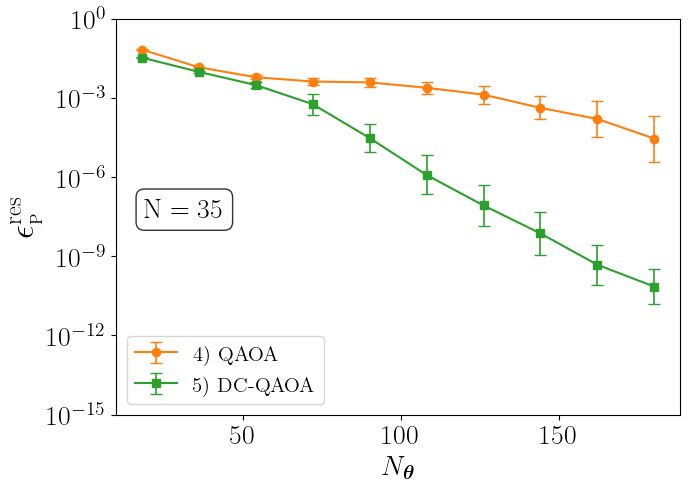

Saved: c:\Users\kiran\OneDrive - SISSA\Desktop\Folder_GitHub\Final_Results\Eres_Diff_Jf_N_35.pdf


In [ ]:
# ============================================================
# PLOT CONTROL
# Uncomment the figure command you want to run.
# Every PDF is saved in FIGURE_DIR.
# ============================================================

#plot_fig2a(N=17);
#plot_fig2b();
#plot_fig3(N=17);
#plot_fig4(N=17);

#plot_fig5(N=17, Jf=0.45);
#plot_fig6(N=35, Jf=0.45, p_index=8, trial=4);
#plot_fig7(N=35, Jf=0.45, p_index=8);
#plot_fig8(N=17, Jf=0.45, p_index=8, trial=4);

#plot_fig9(Jf=0.45);
#plot_fig10(N=17, Jf=0.45, P_index=-2, log_scale=False);
#plot_fig11(N=35);
